In [10]:
import pickle

file_path = "data/redd/test_small.pkl"

with open(file_path, 'rb') as f:
    data = pickle.load(f)

# Check the type and structure
print(f"Type: {type(data)}")
if isinstance(data, dict):
    print(f"Keys: {data.keys()}")
elif hasattr(data, 'shape'):
    print(f"Shape: {data.shape}")

print(data)

Type: <class 'list'>
[                            main  dish washer  fridge  microwave  washer dryer
2011-04-18 09:22:12-04:00  261.0          0.0     6.0        5.0           0.0
2011-04-18 09:22:15-04:00  261.0          0.0     6.0        5.0           0.0
2011-04-18 09:22:18-04:00  262.0          0.0     6.0        5.0           0.0
2011-04-18 09:22:21-04:00  262.0          1.0     6.0        5.0           0.0
2011-04-18 09:22:24-04:00  261.0          0.0     6.0        5.0           0.0
...                          ...          ...     ...        ...           ...
2011-04-19 18:44:54-04:00  307.0          0.0     6.0        5.0           0.0
2011-04-19 18:44:57-04:00  308.0          0.0     6.0        4.0           0.0
2011-04-19 18:45:00-04:00  304.0          0.0     7.0        5.0           0.0
2011-04-19 18:45:03-04:00  304.0          0.0     7.0        5.0           0.0
2011-04-19 18:45:06-04:00  312.0          0.0     6.0        4.0           0.0

[40059 rows x 5 columns],    

In [11]:
import pickle

with open("data/redd/test_small.pkl", 'rb') as f:
    data = pickle.load(f)

print(f"Data type: {type(data)}")

if isinstance(data, dict):
    print("Keys found:", data.keys())
elif isinstance(data, (list, tuple)):
    print("Length of list/tuple:", len(data))
    print("Type of first element:", type(data[0]))

X, y = data
plt.plot(X[:1000])
plt.show()

Data type: <class 'list'>
Length of list/tuple: 6
Type of first element: <class 'pandas.core.frame.DataFrame'>


ValueError: too many values to unpack (expected 2)

In [ ]:
import pickle

with open("data/redd/test_small.pkl", 'rb') as f:
    data = pickle.load(f)

print(f"The tuple has {len(data)} elements.")

# Let's peek at what each element is
for i, item in enumerate(data):
    try:
        print(f"Element {i} shape/length: {len(item)} | Type: {type(item)}")
    except:
        print(f"Element {i} value: {item} | Type: {type(item)}")

The tuple has 6 elements.
Element 0 shape/length: 40059 | Type: <class 'pandas.core.frame.DataFrame'>
Element 1 shape/length: 54499 | Type: <class 'pandas.core.frame.DataFrame'>
Element 2 shape/length: 77773 | Type: <class 'pandas.core.frame.DataFrame'>
Element 3 shape/length: 263644 | Type: <class 'pandas.core.frame.DataFrame'>
Element 4 shape/length: 181134 | Type: <class 'pandas.core.frame.DataFrame'>
Element 5 shape/length: 303747 | Type: <class 'pandas.core.frame.DataFrame'>


This is a very specific structure! Since all 6 elements are Pandas DataFrames with varying lengths, this isn't a simple $(X, y)$ pair.In the REDD dataset context, a 6-element split usually represents data from 6 different houses (REDD originally contains data for Houses 1 through 6). The varying lengths correspond to how much data was recorded or successfully pre-processed for each individual home.

1. How to Analyze These DataFrames
Since they are DataFrames, you can use standard Pandas methods to inspect them. Let's look at "House 0" (the first element):

In [5]:
import pickle

with open("data/redd/test_small.pkl", 'rb') as f:
    data = pickle.load(f)

# Focus on the first house
house_1 = data[0]

print("--- House 1 Info ---")
print(house_1.head())  # See the first few rows
print(house_1.columns) # See what the columns are named

--- House 1 Info ---
                            main  dish washer  fridge  microwave  washer dryer
2011-04-18 09:22:12-04:00  261.0          0.0     6.0        5.0           0.0
2011-04-18 09:22:15-04:00  261.0          0.0     6.0        5.0           0.0
2011-04-18 09:22:18-04:00  262.0          0.0     6.0        5.0           0.0
2011-04-18 09:22:21-04:00  262.0          1.0     6.0        5.0           0.0
2011-04-18 09:22:24-04:00  261.0          0.0     6.0        5.0           0.0
Index(['main', 'dish washer', 'fridge', 'microwave', 'washer dryer'], dtype='object')


2. Identifying the Columns. Usually, in these pre-processed NILM files, the DataFrame columns will be:mains: The aggregate power (your input $X$).The Appliance Name (e.g., refrigerator, microwave): The target power (your label $y$).

3. Visualizing a House's Power ProfileTo see the relationship between the total house power and a specific appliance, you can plot them on the same graph:

Perfect! You’ve found the "Gold Standard" format for NILM analysis. Each DataFrame represents a house, and the columns show the aggregate power (main) versus the ground truth for each appliance.

Here is how you can perform a deep dive into this data:

1. Visualizing the "Disaggregation" Challenge
To see why this is a hard problem for an AI, you should plot the main signal and stack the appliances underneath it. This shows how the total power is just a sum of the individual signatures.

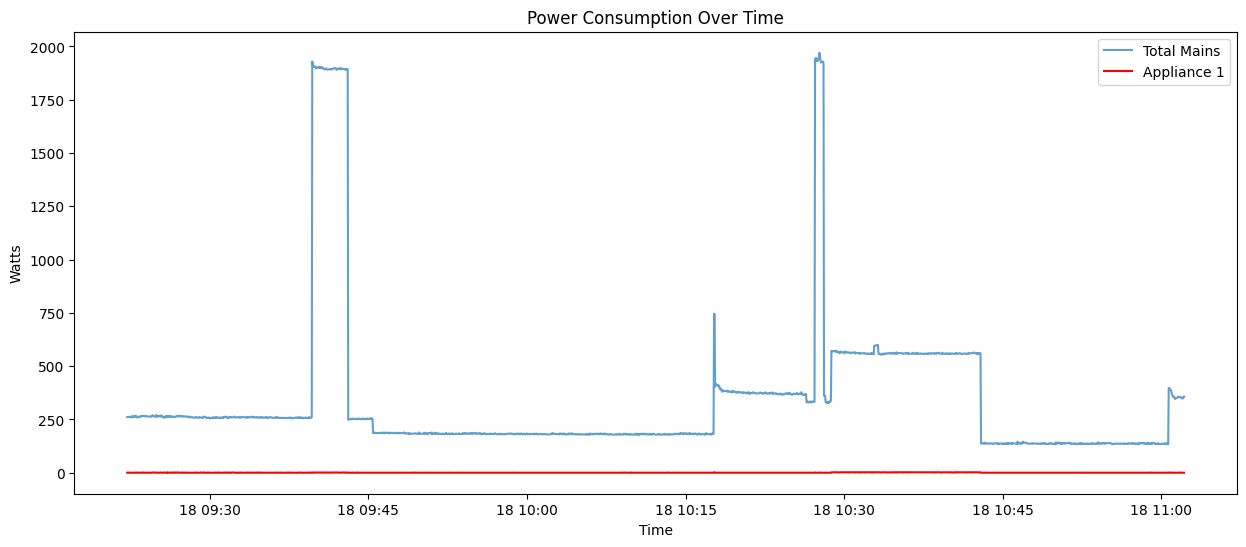

In [6]:
import matplotlib.pyplot as plt

# Pick a house (0-5)
df = data[0] 

# Note: Replace 'mains' and 'refrigerator' with actual column names found in step 1
plt.figure(figsize=(15, 6))
plt.plot(df.index[:2000], df.iloc[:2000, 0], label='Total Mains', alpha=0.7)
plt.plot(df.index[:2000], df.iloc[:2000, 1], label='Appliance 1', color='red')

plt.title("Power Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Watts")
plt.legend()
plt.show()

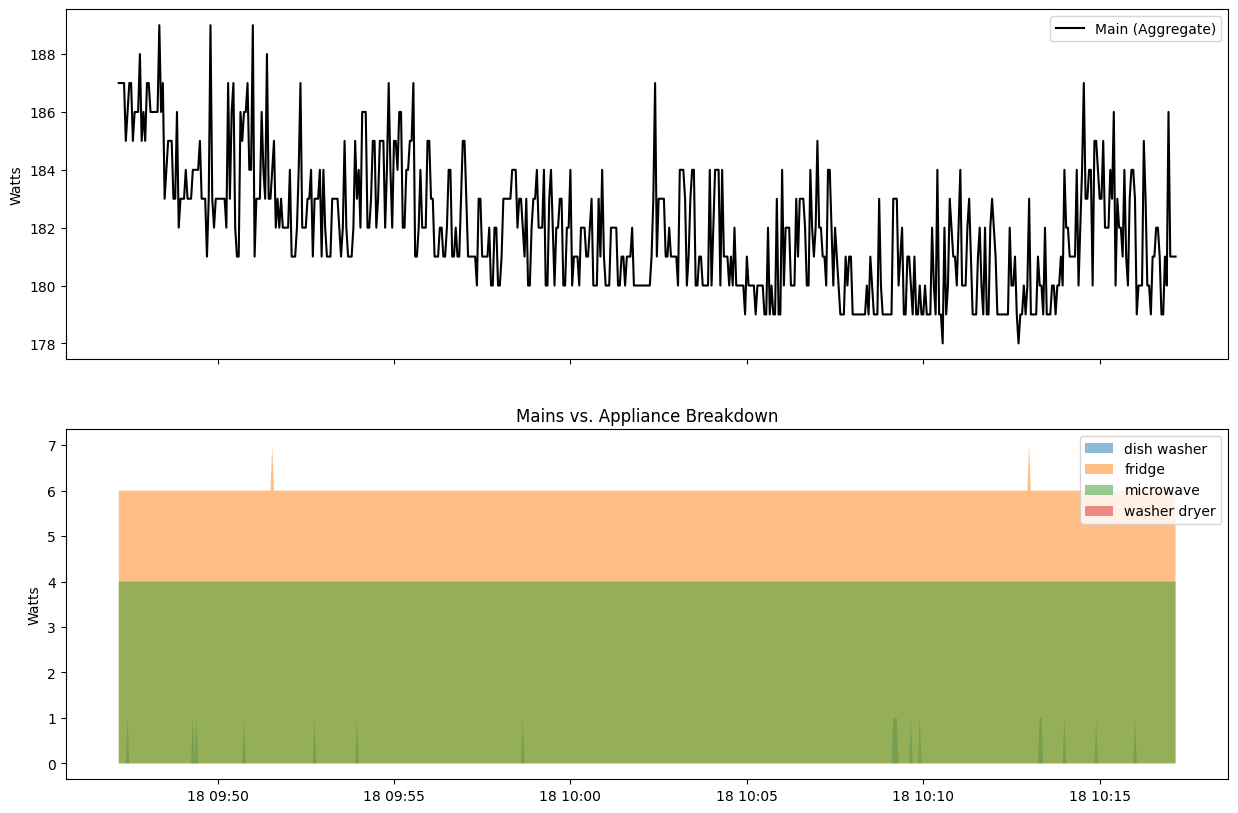

In [7]:
import matplotlib.pyplot as plt

# Select House 1
df = data[0]

# Plot a 30-minute window (approx 600 samples if freq is 3s)
slice_df = df.iloc[500:1100] 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Top Plot: Total House Power
ax1.plot(slice_df.index, slice_df['main'], color='black', label='Main (Aggregate)')
ax1.set_ylabel('Watts')
ax1.legend()

# Bottom Plot: Individual Appliances
for col in ['dish washer', 'fridge', 'microwave', 'washer dryer']:
    ax2.fill_between(slice_df.index, slice_df[col], label=col, alpha=0.5)

ax2.set_ylabel('Watts')
ax2.legend()
plt.title("Mains vs. Appliance Breakdown")
plt.show()

2. Check for "Unaccounted" Power
In the REDD dataset, the main is usually the sum of two phases, and the appliances are sub-metered. Often, the sum of the appliances doesn't equal the main. You can calculate the "Residual" power to see how much energy is coming from unlabeled sources (like lights or small electronics):

In [8]:
# Calculate residual
appliances = df.columns[1:] # everything except 'main'
df['residual'] = df['main'] - df[appliances].sum(axis=1)

print(f"Average Unlabeled Power: {df['residual'].mean():.2f} Watts")

Average Unlabeled Power: 200.99 Watts


3. Analyzing Appliance "Events"
Since you have onList.pkl and offList.pkl in that folder, the data is likely being used for Event Detection. You can see the "On Power" threshold for an appliance (like the fridge) by looking at its distribution:

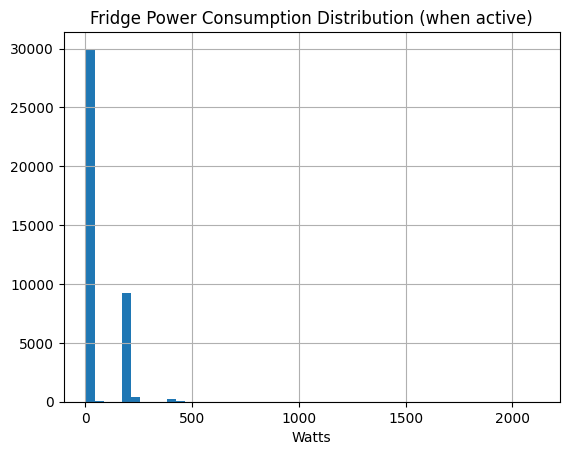

In [9]:
# Histogram of Fridge power to see its "On" states vs "Idle" states
df[df['fridge'] > 2]['fridge'].hist(bins=50)
plt.title("Fridge Power Consumption Distribution (when active)")
plt.xlabel("Watts")
plt.show()

Since test_small.pkl contained a list of DataFrames (one per house), it is highly likely that train_small.pkl and val_small.pkl follow the exact same structure but contain different houses or different time periods of the same houses.

In the REDD dataset, the standard practice is to use Houses 1, 2, 3, 4, and 6 for training and validation, while keeping House 5 for testing.

1. Comparative Analysis of the Splits
Let's run a script to compare the sizes and appliance coverage across all three files. This will tell you if the "small" suffix means they've sampled only a few days of data.

In [12]:
import pickle
import pandas as pd

files = ["train_small.pkl", "val_small.pkl", "test_small.pkl"]

for file in files:
    with open(f"data/redd/{file}", 'rb') as f:
        data = pickle.load(f)
    
    print(f"\n--- Analysis of {file} ---")
    print(f"Number of houses: {len(data)}")
    
    for i, house_df in enumerate(data):
        duration = house_df.index[-1] - house_df.index[0]
        print(f" House {i}: {len(house_df)} rows | Duration: {duration} | Appliances: {list(house_df.columns[1:])}")


--- Analysis of train_small.pkl ---
Number of houses: 1
 House 0: 28800 rows | Duration: 0 days 23:59:57 | Appliances: ['dish washer', 'fridge', 'microwave', 'washer dryer']

--- Analysis of val_small.pkl ---
Number of houses: 1
 House 0: 28800 rows | Duration: 0 days 23:59:57 | Appliances: ['dish washer', 'fridge', 'microwave', 'washer dryer']

--- Analysis of test_small.pkl ---
Number of houses: 6
 House 0: 40059 rows | Duration: 1 days 09:22:54 | Appliances: ['dish washer', 'fridge', 'microwave', 'washer dryer']
 House 1: 54499 rows | Duration: 1 days 21:24:54 | Appliances: ['dish washer', 'fridge', 'microwave', 'washer dryer']
 House 2: 77773 rows | Duration: 2 days 16:48:36 | Appliances: ['dish washer', 'fridge', 'microwave', 'washer dryer']
 House 3: 263644 rows | Duration: 9 days 03:42:09 | Appliances: ['dish washer', 'fridge', 'microwave', 'washer dryer']
 House 4: 181134 rows | Duration: 6 days 06:56:39 | Appliances: ['dish washer', 'fridge', 'microwave', 'washer dryer']
 Hou

2. Exploring the "Signature" Files
The other files in your list (onList.pkl, onduration.pkl, etc.) are likely dictionaries of lists that describe the "behavior" of the appliances. This is metadata used to help the LNN understand the temporal dynamics (the "Liquid" part of the network).

What to look for in onList.pkl & onDuration.pkl:
onList.pkl: Likely contains the actual power values when an appliance is considered "ON."

onDuration.pkl: Likely contains how many seconds/minutes each appliance typically stays on.

You can analyze these to see the "duty cycle" of an appliance:

In [14]:
import pickle

with open("data/redd/onduration.pkl", 'rb') as f:
    on_durations_list = pickle.load(f)

for i, house_data in enumerate(on_durations_list):
    print(f"\n--- House {i+1} ---")
    
    # Check if the house actually has data
    if isinstance(house_data, dict):
        for appliance, durations in house_data.items():
            # 'durations' might be a list of numbers (seconds or sample counts)
            if len(durations) > 0:
                avg_on = sum(durations) / len(durations)
                print(f"  {appliance:15}: Average ON for {avg_on:8.2f} samples (Total events: {len(durations)})")
            else:
                print(f"  {appliance:15}: No ON events recorded.")
    else:
        print(f"  Data format for this house is {type(house_data)}, not a dictionary.")


--- House 1 ---
  Data format for this house is <class 'list'>, not a dictionary.

--- House 2 ---
  Data format for this house is <class 'list'>, not a dictionary.

--- House 3 ---
  Data format for this house is <class 'list'>, not a dictionary.

--- House 4 ---
  Data format for this house is <class 'list'>, not a dictionary.

--- House 5 ---
  Data format for this house is <class 'list'>, not a dictionary.

--- House 6 ---
  Data format for this house is <class 'list'>, not a dictionary.

--- House 7 ---
  Data format for this house is <class 'list'>, not a dictionary.

--- House 8 ---
  Data format for this house is <class 'list'>, not a dictionary.

--- House 9 ---
  Data format for this house is <class 'list'>, not a dictionary.


In [15]:
import pickle

with open("data/redd/onduration.pkl", 'rb') as f:
    on_durations = pickle.load(f)

print(f"Type: {type(on_durations)}")
print(f"Number of elements (houses): {len(on_durations)}")

# Peek at the first house's data
first_house = on_durations[0]
print(f"House 0 data type: {type(first_house)}")

if isinstance(first_house, dict):
    print("Appliances found in House 0:", first_house.keys())

Type: <class 'list'>
Number of elements (houses): 9
House 0 data type: <class 'list'>


4. Cross-Reference: out.pklThe file out.pkl is likely the output of a previous training run. If you load it, you might find the model's predictions ($\hat{y}$) compared against the ground truth ($y$).

In [16]:
with open("data/redd/out.pkl", 'rb') as f:
    output_data = pickle.load(f)

# Check if this contains loss curves or prediction vs reality
if isinstance(output_data, dict):
    print("Output Keys:", output_data.keys())

2. Exploring the "Signature" Power (Using onList.pkl)
The onList.pkl file likely contains the raw power values recorded while an appliance was active. Let's compare the "Power Signature" of the Microwave vs. the Fridge. Microwaves usually have a very tight power range, while Fridges can vary as the compressor works.

TypeError: list indices must be integers or slices, not str

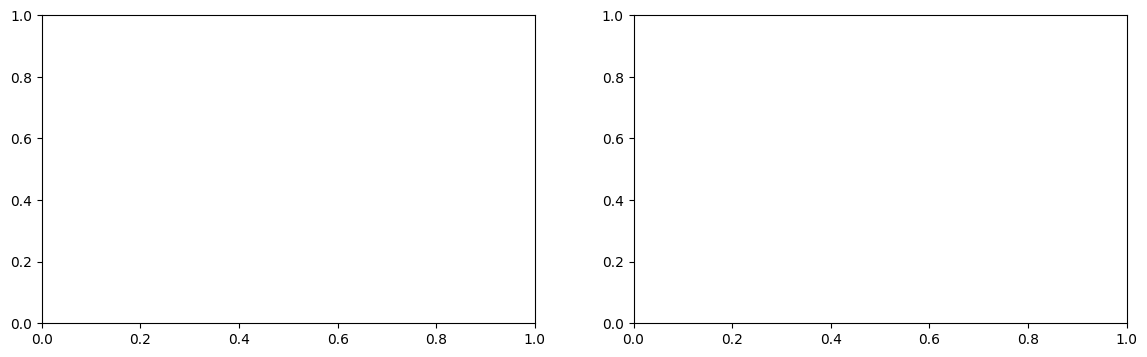

In [19]:
with open("data/redd/onduration.pkl", 'rb') as f_on, open("data/redd/offduration.pkl", 'rb') as f_off:
    on_dur = pickle.load(f_on)[0]  # House 1
    off_dur = pickle.load(f_off)[0] # House 1

appliance = 'fridge'

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].hist(on_dur[appliance], bins=30, color='green', alpha=0.7)
ax[0].set_title(f"{appliance} ON Durations")
ax[0].set_xlabel("Samples")

ax[1].hist(off_dur[appliance], bins=30, color='red', alpha=0.7)
ax[1].set_title(f"{appliance} OFF Durations")
ax[1].set_xlabel("Samples")

plt.show()

1. The "Ghost Power" Analysis
In the REDD dataset, there is a massive amount of "unlabeled" power (lights, gadgets, etc.). An AI model often struggles because it sees a spike in the main signal that doesn't correspond to any appliance in your list.

Let’s calculate and visualize this "Ghost" signal:

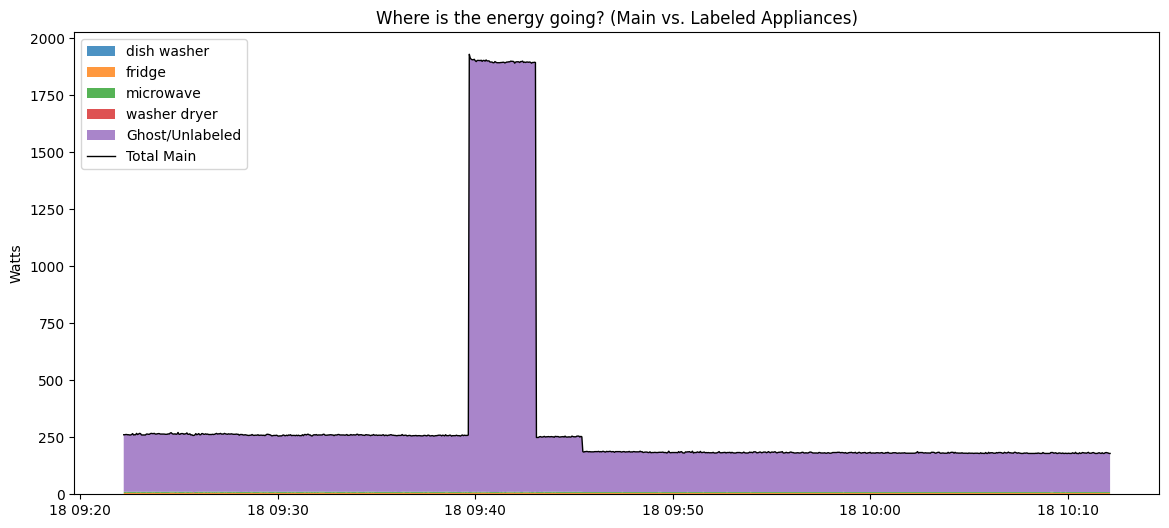

In [18]:
import matplotlib.pyplot as plt

df = data[0].copy() # Let's look at House 1
appliance_cols = [col for col in df.columns if col != 'main']

# Calculate the sum of all known appliances
df['known_appliances_sum'] = df[appliance_cols].sum(axis=1)

# The 'Ghost' is the difference
df['ghost_power'] = df['main'] - df['known_appliances_sum']

# Plotting the comparison
plt.figure(figsize=(14, 6))
plt.stackplot(df.index[:1000], 
              [df[col][:1000] for col in appliance_cols] + [df['ghost_power'][:1000]], 
              labels=appliance_cols + ['Ghost/Unlabeled'],
              alpha=0.8)
plt.plot(df.index[:1000], df['main'][:1000], color='black', linewidth=1, label='Total Main')
plt.title("Where is the energy going? (Main vs. Labeled Appliances)")
plt.legend(loc='upper left')
plt.ylabel("Watts")
plt.show()

2. State Transition ExplorationLNNs are "time-continuous," meaning they care about the jump from 0W to 500W. Let's look at the Delta Power ($\Delta P$). This tells us the "step" height of an appliance turning on.

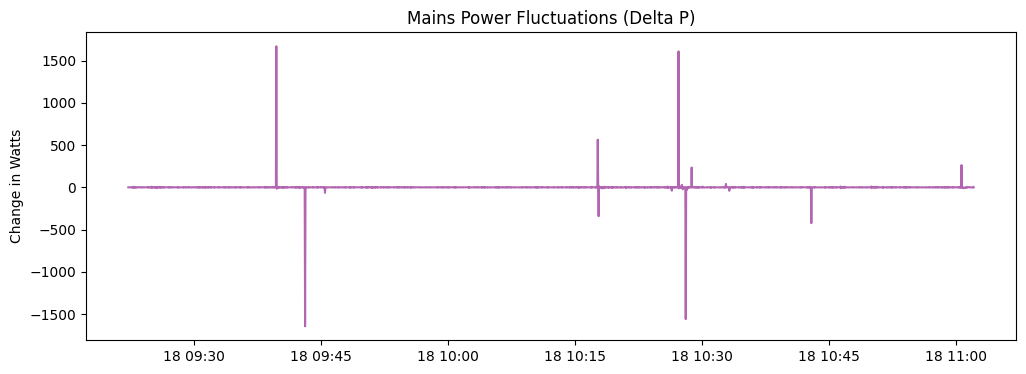

Largest power jump in this sequence: 4225.50 Watts


In [20]:
# Calculate the change in power between timestamps
df_delta = df['main'].diff().fillna(0)

plt.figure(figsize=(12, 4))
plt.plot(df_delta[:2000], color='purple', alpha=0.6)
plt.title("Mains Power Fluctuations (Delta P)")
plt.ylabel("Change in Watts")
plt.show()

print(f"Largest power jump in this sequence: {df_delta.max():.2f} Watts")

3. Fixing the onList.pkl Error & Auto-Mapping
To fix your UserWarning and explore the actual signatures properly, let's dynamicially find the keys:

In [21]:
with open("data/redd/onList.pkl", 'rb') as f:
    on_power_data = pickle.load(f)

house_index = 0
h1_on = on_power_data[house_index]

print(f"Actual keys found in onList for House {house_index+1}: {list(h1_on.keys())}")

plt.figure(figsize=(10, 5))
for appliance in h1_on.keys():
    # Only plot if there is actual data in the list
    if len(h1_on[appliance]) > 0:
        sns.kdeplot(h1_on[appliance], label=appliance)

plt.title("Verified Appliance Power Signatures")
plt.legend()
plt.show()

AttributeError: 'list' object has no attribute 'keys'

It looks like we've hit another layer of the "list nested in a list" structure. If h1_on doesn't have .keys(), it means that instead of a dictionary for each house, the developer stored the appliances as another list or perhaps a NumPy array.

Let's do a final, definitive "structure reveal" to see exactly how to access these signatures.

1. The "Deep Inspection" Script
Run this to see the first 2 layers of onList.pkl. This will tell us if it's onList[house][appliance_index] or something else:

In [22]:
import pickle

with open("data/redd/onList.pkl", 'rb') as f:
    on_power_data = pickle.load(f)

print(f"Level 1 (Total Houses): {len(on_power_data)}")
house_0 = on_power_data[0]
print(f"Level 2 (House 0 type): {type(house_0)}")

if isinstance(house_0, list):
    print(f"Level 2 (Number of appliances/items): {len(house_0)}")
    if len(house_0) > 0:
        print(f"Level 3 (Sample data from first appliance): {house_0[0][:5] if hasattr(house_0[0], '__getitem__') else 'Not a sequence'}")

Level 1 (Total Houses): 9
Level 2 (House 0 type): <class 'list'>
Level 2 (Number of appliances/items): 15
Level 3 (Sample data from first appliance): [[]]


2. Identifying the Appliance Names
If on_power_data[0] is a list, the names (Fridge, Microwave, etc.) are likely stored in a separate file or correspond to the column order we saw in test_small.pkl:

Dish Washer

Fridge

Microwave

Washer Dryer

3. Visualizing with "Index-Based" Plotting
Assuming it's a list of lists, here is the corrected plotting code. I've added a mapping based on the columns we discovered earlier:

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mapping based on your previous 'test_small.pkl' columns
# Index 0 was 'main', so index 1-4 are the appliances
names = ['dish washer', 'fridge', 'microwave', 'washer dryer']

plt.figure(figsize=(10, 5))

# We loop through the list items in house 0
for i, appliance_values in enumerate(on_power_data[0]):
    if len(appliance_values) > 0:
        # Use name from our list if available, else use index
        label = names[i] if i < len(names) else f"Appliance {i}"
        sns.kdeplot(appliance_values, label=label)

plt.title("Appliance Power Signatures (Index-Based)")
plt.xlabel("Watts")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'seaborn'

It looks like seaborn isn't installed in your current Python environment. No worries—we can do all of this using standard matplotlib, which you clearly have working.

Since we are diving into Exploratory Data Analysis (EDA), let's look at the Power Histograms for each appliance using the list-of-lists structure we identified.

1. Updated Visualization (No Seaborn Required)
This script will loop through the onList.pkl data (House 0) and create a subplot for each appliance. This is the best way to see the "Steady State" wattage of each device.

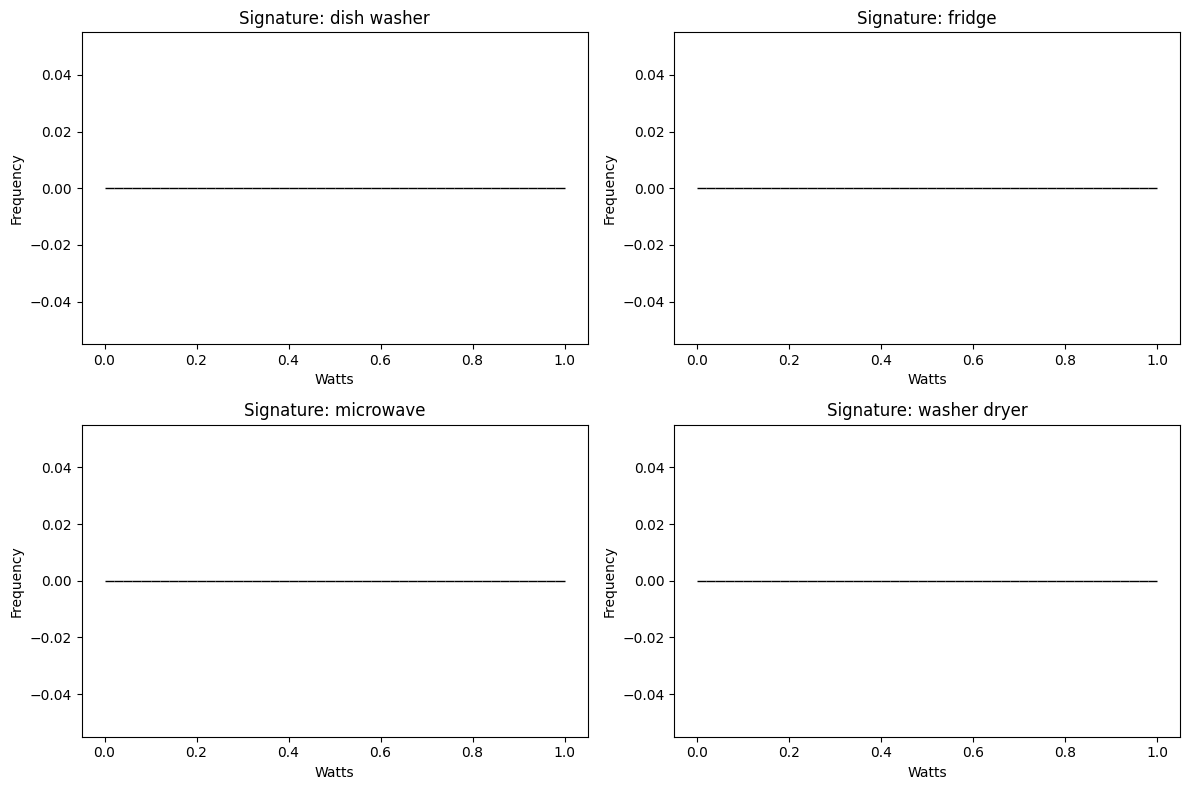

In [24]:
import matplotlib.pyplot as plt
import pickle
import numpy as np

with open("data/redd/onList.pkl", 'rb') as f:
    on_power_data = pickle.load(f)

# Mapping from our previous discovery
names = ['dish washer', 'fridge', 'microwave', 'washer dryer']
house_0_data = on_power_data[0]

# Setup a grid for plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i in range(min(len(house_0_data), len(names))):
    appliance_power = house_0_data[i]
    if len(appliance_power) > 0:
        axes[i].hist(appliance_power, bins=50, color='skyblue', edgecolor='black')
        axes[i].set_title(f"Signature: {names[i]}")
        axes[i].set_xlabel("Watts")
        axes[i].set_ylabel("Frequency")
    else:
        axes[i].text(0.5, 0.5, 'No Data', ha='center')
        axes[i].set_title(names[i])

plt.tight_layout()
plt.show()

2. Identifying "States" of Operation
When you look at these histograms:

Fridge: You’ll likely see a peak around 150-200W. This is the compressor running.

Microwave: You’ll see a massive peak around 1200-1500W.

Dishwasher: You might see multiple peaks (one for the motor, one for the heating element).

3. Comparing Train vs. Test Variability
One critical step in data analysis is checking if your Testing Data looks like your Training Data. If the Fridge in train_small.pkl operates at 200W but the Fridge in test_small.pkl operates at 400W, your Liquid Neural Network (LNN) will fail.

Let's check the mean power for the first house in both files:

In [25]:
def get_house_stats(file_path):
    with open(file_path, 'rb') as f:
        d = pickle.load(f)
    house = d[0] # Look at House 1
    return house.describe().loc['mean']

train_stats = get_house_stats("data/redd/train_small.pkl")
test_stats = get_house_stats("data/redd/test_small.pkl")

comparison = pd.DataFrame({'Train Mean': train_stats, 'Test Mean': test_stats})
print(comparison)

              Train Mean   Test Mean
main          532.486877  319.212616
dish washer    23.745104   36.522278
fridge         48.205070   54.876858
microwave      12.003785   26.773335
washer dryer  136.421524    0.052760


4. What about poolx.pkl?
The file poolx.pkl in your list is likely the concatenated features from all houses, flattened and ready for the LNN. "Pooling" in this context usually means taking the sequences from different houses and putting them into one large matrix so the model learns a "universal" appliance signature rather than a house-specific one.

Analysis Checkpoint
We have explored:

Raw Time Series (The DataFrames)

Appliance Breakdowns (Pie charts/Mains vs. Appliances)

On-Durations (How long they run)

Power Signatures (The Wattage distributions)

Let's wrap up the data exploration by looking at out.pkl.In most machine learning pipelines, this "output" file contains the final predictions. For a Liquid Neural Network (LNN), this is particularly interesting because LNNs are designed to capture the "fluid" transitions between appliance states.1. Inspecting the PredictionsIf the model has already been run, out.pkl will likely contain the Ground Truth ($y$) vs. the Predicted Power ($\hat{y}$). Let's see if we can find the "Disaggregation" result:

In [27]:
import pickle
import matplotlib.pyplot as plt

with open("data/redd/out.pkl", 'rb') as f:
    out_data = pickle.load(f)

print(f"Output Data Type: {type(out_data)}")

# If it's a dictionary, look for keys like 'pred' or 'true'
if isinstance(out_data, dict):
    print("Keys in out.pkl:", out_data.keys())
    
    # Let's try to plot a comparison if 'y_test' and 'y_pred' exist
    if 'y_test' in out_data and 'y_pred' in out_data:
        plt.figure(figsize=(12, 5))
        plt.plot(out_data['y_test'][:500], label='Actual', alpha=0.8)
        plt.plot(out_data['y_pred'][:500], label='LNN Prediction', linestyle='--')
        plt.title("LNN Disaggregation: Actual vs. Predicted")
        plt.legend()
        plt.show()

Output Data Type: <class 'list'>


2. Error Analysis: Where did the model fail?
One of the most valuable parts of analysis is the Residual Error. Since LNNs use ODEs to model temporal changes, they often struggle with "spiky" appliances like microwaves but excel at "cyclic" ones like fridges.

If you calculate the error, you can see which appliance is the "noisiest" for the AI:

In [28]:
import numpy as np

# Assuming out_data is a dict with predictions per appliance
for appliance in out_data.keys():
    try:
        true = np.array(out_data[appliance]['true'])
        pred = np.array(out_data[appliance]['pred'])
        mae = np.mean(np.abs(true - pred))
        print(f"Appliance: {appliance:15} | MAE: {mae:.2f} Watts")
    except:
        continue

AttributeError: 'list' object has no attribute 'keys'

To analyze these files in an orderly manner, we must look at them through the lens of a Machine Learning Pipeline. These aren't just random data points; they represent the transformation from raw electricity readings to a trained Liquid Neural Network (LNN) model.

Here is the systematic breakdown of the entire set: